In [1]:
import numpy as np 
import pandas as pd 
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt 
import tensorflow as tf

In [2]:
df = pd.read_csv('https://drive.google.com/uc?id=15RfMD9lNkpS3cVN7j3_dsJKZ8_5RJG5z')
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [3]:
df.isnull().sum()

,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


In [4]:
date = df['date'].values
temp = df['meantemp'].values

date

array(['2013-01-01', '2013-01-02', '2013-01-03', ..., '2016-12-30',
       '2016-12-31', '2017-01-01'], dtype=object)

Text(0.5, 1.0, 'Temperature Average')

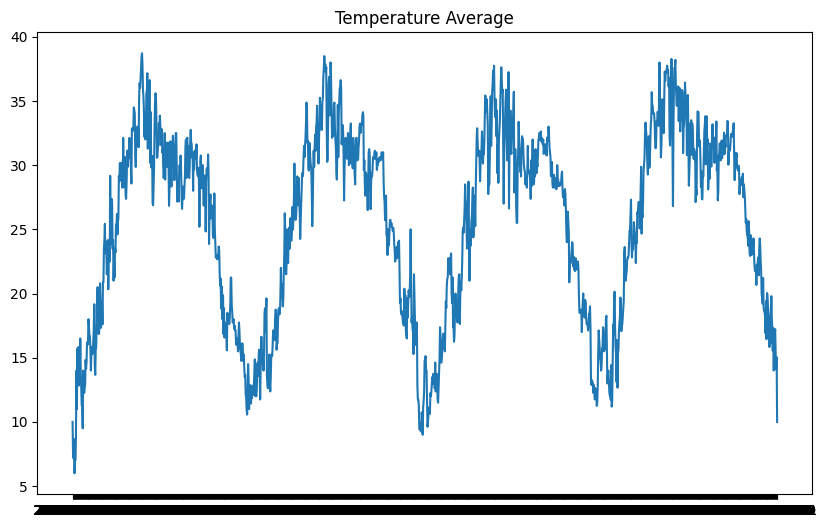

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(date, temp)
plt.title("Temperature Average")

In [9]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    series = tf.expand_dims(series, axis=-1)
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))
    ds = ds.shuffle(shuffle_buffer)
    ds = ds.map(lambda w: (w[:-1], w[-1:]))
    return ds.batch(batch_size).prefetch(1)

In [10]:
train_set = windowed_dataset(temp, window_size=60, batch_size=100, shuffle_buffer=1000)
model = tf.keras.models.Sequential([
  tf.keras.layers.LSTM(60, return_sequences=True),
  tf.keras.layers.LSTM(60),
  tf.keras.layers.Dense(30, activation="relu"),
  tf.keras.layers.Dense(10, activation="relu"),
  tf.keras.layers.Dense(1),
])

In [12]:
optimizer = tf.keras.optimizers.SGD(learning_rate=1.0000e-04, momentum=0.9)
model.compile(loss=tf.keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])
history = model.fit(train_set,epochs=100)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 25.3353 - mae: 25.8353
Epoch 2/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 25.2967 - mae: 25.7967
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 25.2460 - mae: 25.7460
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 25.1855 - mae: 25.6855
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 25.0889 - mae: 25.5889
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 24.9751 - mae: 25.4751
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 24.8639 - mae: 25.3639
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 24.7457 - mae: 25.2457
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 24.6185 - mae: 25.1185
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 24.4812 - mae: 24.9812
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 24.3290 - mae: 24.8290
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - loss: 24.1580 - mae: 24.6580
Epoch 13/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 23.9640 - mae: 24.4640
Epoch 14/10

In [13]:
forecast = history.model.predict(train_set)
forecast

15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step


array([[14.06123 ],
       [30.23838 ],
       [13.162649],
       ...,
       [14.094122],
       [34.538803],
       [22.275394]], dtype=float32)